In [274]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [275]:
# データの読み込み
df = pd.read_csv('../data/Daily_fixed.csv')

# ticker_codeが4桁の数字かどうかを確認する関数
def is_four_digit_number(x):
    if isinstance(x, str):
        return x.isdigit() and len(x) == 4
    return False

# フィルタリング
df_filtered = df[df['TICKER_CODE'].apply(is_four_digit_number)]

# 結果の確認
print("元のデータ件数:", len(df))
print("フィルタリング後のデータ件数:", len(df_filtered))

# フィルタリング後のデータを表示
df_filtered.head()

元のデータ件数: 3036242
フィルタリング後のデータ件数: 2913496


,DATE,ROW_COUNT,TOTAL_SALES,TICKER_CODE,BRAND_CODE,BRAND_NAME_EN
0,2020-11-10,10984,41662029,4385,543,Mercari
3,2020-04-08,2224,6372041,3382,411,York Benimaru
5,2020-11-10,1924,7563620,8028,788,Apita
6,2020-11-10,3075,9397159,8267,1159,Aeon Retail
7,2020-11-10,76,219216,8267,1128,Aeon Town


In [276]:
# DATEを日付型に変換
df_filtered['DATE'] = pd.to_datetime(df_filtered['DATE'])

# 月単位の集計用に '年月' 列を追加
df_filtered['年月'] = df_filtered['DATE'].dt.to_period('M')

# TICKER_CODEごと、月ごとに合計
monthly_total = df_filtered.groupby(['年月', 'TICKER_CODE'])['TOTAL_SALES'].sum().reset_index()

# 列名を分かりやすく
monthly_total.rename(columns={'年月': 'DATE'}, inplace=True)

monthly_total

C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\1827593477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['DATE'] = pd.to_datetime(df_filtered['DATE'])
C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\1827593477.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['年月'] = df_filtered['DATE'].dt.to_period('M')


,DATE,TICKER_CODE,TOTAL_SALES
0,2020-02,2138,25074730
1,2020-02,2157,18264445
2,2020-02,2193,1609970
3,2020-02,2211,5580968
4,2020-02,2267,45034357
...,...,...,...
15211,2025-05,9974,69938430
15212,2025-05,9983,570275236
15213,2025-05,9984,1135859954
15214,2025-05,9989,38769885


In [277]:
# 成長率の計算
monthly_total['prev_month_sales'] = monthly_total.groupby('TICKER_CODE')['TOTAL_SALES'].shift(1)
monthly_total['growth_rate'] = (monthly_total['TOTAL_SALES'] - monthly_total['prev_month_sales']) / monthly_total['prev_month_sales'] * 100
monthly_total = monthly_total.dropna(subset=['growth_rate'])
latest_month = monthly_total['DATE'].max()

# # 各ティッカーごとに最初の月を特定
# first_month_idx = monthly_total.groupby('TICKER_CODE')['DATE'].idxmin()

# # その行を除外
# monthly_total = monthly_total.drop(first_month_idx)

# 最新月を除外
monthly_total = monthly_total[monthly_total['DATE'] != latest_month]

# 結果の表示
print("月次売上成長率:")
monthly_total.sort_values(['TICKER_CODE', 'DATE'])

月次売上成長率:


,DATE,TICKER_CODE,TOTAL_SALES,prev_month_sales,growth_rate
237,2020-03,2138,29300928,25074730.0,16.854411
474,2020-04,2138,38294758,29300928.0,30.694693
711,2020-05,2138,50329051,38294758.0,31.425432
948,2020-06,2138,42749087,50329051.0,-15.060812
1185,2020-07,2138,54825149,42749087.0,28.248702
...,...,...,...,...,...
14031,2024-12,9997,112372737,105326045.0,6.690360
14269,2025-01,9997,76877994,112372737.0,-31.586614
14507,2025-02,9997,81237922,76877994.0,5.671230
14745,2025-03,9997,104982526,81237922.0,29.228473


C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\508812131.py:14: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\508812131.py:14: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\508812131.py:14: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\508812131.py:14: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\508812131.py:14: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hh080\AppData\Local\Temp\ipykernel_8488\508812131.py:14: UserWarning: Glyph 22770 (\N{CJK UNIFIE

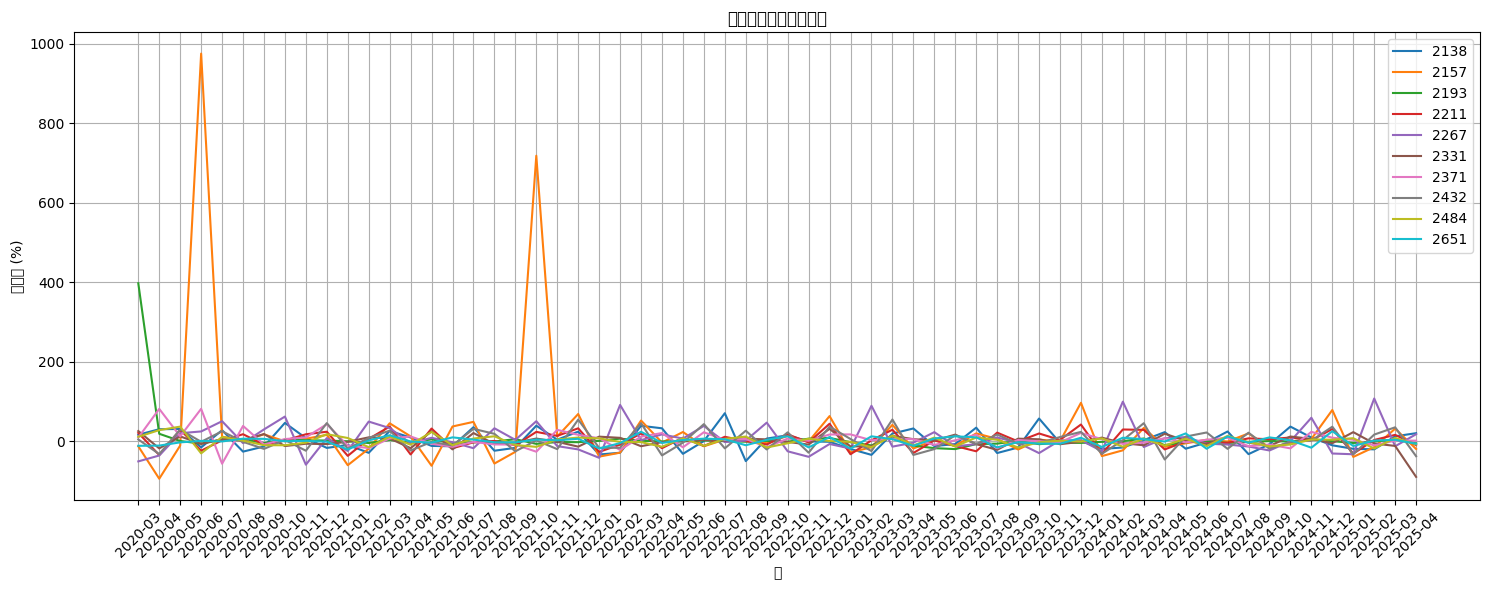

In [278]:
# 成長率の可視化
plt.figure(figsize=(15, 6))
for ticker in monthly_total['TICKER_CODE'].unique()[:10]:  # 最初の5つのブランドのみ表示
    brand_data = monthly_total[monthly_total['TICKER_CODE'] == ticker]
    brand_name = ticker
    plt.plot(brand_data['DATE'].astype(str), brand_data['growth_rate'], label=brand_name)

plt.title('月次売上成長率の推移')
plt.xlabel('月')
plt.ylabel('成長率 (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [279]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


In [ ]:
# def fetch_stock_prices(df): # function to fetch stock prices
#     tickers = df['TICKER_CODE'].unique()
    
#     start_date = df['DATE'].min()
#     end_date = df['DATE'].max()
    
#     price_data = pd.DataFrame()
    
#     # get stock prices for each ticker
#     for ticker in tickers:
#         try:
#             ticker_str = str(ticker).zfill(4) + '.T'
            
#             # get stock prices and dividends
#             stock = yf.Ticker(ticker_str)
#             hist = stock.history(start=start_date, end=end_date)
            
#             # organize data
#             hist = hist.reset_index()
#             hist['ticker_code'] = ticker
#             hist['date'] = hist['Date'].dt.strftime('%Y-%m-%d')
#             hist = hist[['date', 'ticker_code', 'Close', 'Dividends']]
#             hist.columns = ['date', 'ticker_code', 'price', 'dividends']
            
#             price_data = pd.concat([price_data, hist])
            
#             print(f'Successfully fetched data for {ticker}')
#             time.sleep(1)  # Add delay to avoid rate limiting
            
#         except Exception as e:
#             print(f'Failed to fetch data for {ticker}: {str(e)}')
    
#     return price_data

price_data = pd.read_csv('../data/price_data.csv')

price_data['monthly_return']

# print(fetch_stock_prices(monthly_total))

$2651.T: possibly delisted; no timezone found
$2928.T: possibly delisted; no timezone found
$3098.T: possibly delisted; no timezone found
$3938.T: possibly delisted; no timezone found
$4348.T: possibly delisted; no timezone found
$4921.T: possibly delisted; no timezone found
$7323.T: possibly delisted; no timezone found
$7618.T: possibly delisted; no timezone found
$7816.T: possibly delisted; no timezone found
$8028.T: possibly delisted; no timezone found
$8114.T: possibly delisted; no timezone found
$8168.T: possibly delisted; no timezone found
$8182.T: possibly delisted; no timezone found
$8184.T: possibly delisted; no timezone found
$9783.T: possibly delisted; no timezone found
$9792.T: possibly delisted; no timezone found
$9873.T: possibly delisted; no timezone found
$9919.T: possibly delisted; no timezone found
$9945.T: possibly delisted; no timezone found


Failed to fetch data for 2138: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2157: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2193: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2211: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2267: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2331: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2371: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2432: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2484: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2651: Can only use .dt accessor with datetimelike values
Failed to fetch data for 2659: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2670: 'Period' object has no attribute 'timestamp'
Failed to fetch data for 2678: 'Period' object has no attribute 'timestamp'
Failed

In [ ]:
def calculate_quantile_weights(df):
    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m')
    
    # calculate quantile of sales for each month
    df['quantile'] = df.groupby('date')['sales'].transform(
        lambda x: pd.qcut(x, q=4, labels=False, duplicates='drop')
    )
    
    # convert ticker codes to matrix format
    quantile_matrix = pd.pivot_table(
        df,
        values='sales',
        index=['date', 'ticker_code'],
        columns='quantile',
        aggfunc='count',
        fill_value=0
    ).reset_index()
    
    # calculate number of ticker codes for each quantile
    quantile_counts = df.groupby(['date', 'quantile'])['ticker_code'].count().reset_index()
    quantile_counts.columns = ['date', 'quantile', 'count']
    
    # calculate equal-weighted weights
    for quantile in range(4):
        for date in quantile_matrix['date'].unique():
            
            # get number of ticker codes for that date and quantile
            count = quantile_counts.loc[
                (quantile_counts['date'] == date) & 
                (quantile_counts['quantile'] == quantile), 'count'
            ].values[0] if not quantile_counts.loc[
                (quantile_counts['date'] == date) & 
                (quantile_counts['quantile'] == quantile), 'count'
            ].empty else 0
            
            # calculate weights
            mask = (quantile_matrix['date'] == date)
            quantile_matrix.loc[mask, quantile] = quantile_matrix.loc[mask, quantile].apply(
                lambda x: 1/count if x == 1 and count > 0 else 0
            )
    
    return quantile_matrix


def calculate_returns(price_data):
    # 日付を月次に変換
    price_data['date'] = pd.to_datetime(price_data['date']).dt.strftime('%Y-%m')
    
    # 重複を避けるために、日付とティッカーでグループ化して最新のデータを使用
    price_data = price_data.sort_values('date').groupby(['date', 'ticker_code']).last().reset_index()
    
    # 月次リターンの計算（配当込み）
    price_data['monthly_return'] = price_data.groupby('ticker_code').apply(
        lambda x: (x['price'] + x['dividends'].fillna(0)) / x['price'].shift(1) - 1,
        include_groups=False
    ).reset_index(level=0, drop=True)
    
    # マトリックス形式に変換
    return_matrix = pd.pivot_table(
        price_data,
        values='monthly_return',
        index=['date', 'ticker_code'],
        aggfunc='mean'
    ).reset_index()
    
    return return_matrix


def calculate_portfolio_returns(weights, returns):
    # merge data
    portfolio_data = pd.merge(weights, returns, on=['date', 'ticker_code'])
    
    # calculate portfolio returns for each quantile
    portfolio_returns = pd.DataFrame()
    portfolio_returns['date'] = portfolio_data['date'].unique()
    
    for quantile in range(4):
        portfolio_returns[f'quantile_{quantile}_return'] = portfolio_data.groupby('date').apply(
            lambda x: np.sum(x[quantile] * x['monthly_return'])
        ).values
    
    return portfolio_returns


def plot_cumulative_returns(portfolio_returns):
    portfolio_returns['date'] = pd.to_datetime(portfolio_returns['date'])
    
    # calculate cumulative returns
    for quantile in range(4):
        portfolio_returns[f'cumulative_quantile_{quantile}_return'] = (
            1 + portfolio_returns[f'quantile_{quantile}_return']
        ).cumprod()
    
    # plot graph
    plt.figure(figsize=(12, 6))
    
    for quantile in range(4):
        plt.plot(
            portfolio_returns['date'],
            portfolio_returns[f'cumulative_quantile_{quantile}_return'],
            label=f'Quantile {quantile+1}'
        )
    
    plt.title('Cumulative Returns by Quantile')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.savefig('../data/output1/cumulative_returns.png')


def main():
    df = pd.read_csv('../data/62895811-957f-456c-8b2e-34a48d8361ff.csv')
    df = data_preprocessing(df)
    
    # get stock prices
    price_data = fetch_stock_prices(df)
    
    # calculate quantile and weights
    quantile_weights = calculate_quantile_weights(df)
    
    # calculate stock returns
    returns = calculate_returns(price_data)
    
    # calculate portfolio returns
    portfolio_returns = calculate_portfolio_returns(quantile_weights, returns)
    
    # plot cumulative returns
    plot_cumulative_returns(portfolio_returns)
    
    # save results
    price_data.to_csv('../data/output1/price_data.csv', index=False)
    quantile_weights.to_csv('../data/output1/quantile_portfolio_weights.csv', index=False)
    returns.to_csv('../data/output1/monthly_returns.csv', index=False)
    portfolio_returns.to_csv('../data/output1/portfolio_returns.csv', index=False)
    
    print('Done')


if __name__ == '__main__':
    main() 

FileNotFoundError: [Errno 2] No such file or directory: '../data/62895811-957f-456c-8b2e-34a48d8361ff.csv'